# Spaceship Titanic

**Kaggle competitions**

Welcome to the year 2912, where your data science skills are needed to solve a cosmic mystery. We've received a transmission from four lightyears away and things aren't looking good.

The Spaceship Titanic was an interstellar passenger liner launched a month ago. With almost 13,000 passengers on board, the vessel set out on its maiden voyage transporting emigrants from our solar system to three newly habitable exoplanets orbiting nearby stars.

While rounding Alpha Centauri en route to its first destination—the torrid 55 Cancri E—the unwary Spaceship Titanic collided with a spacetime anomaly hidden within a dust cloud. Sadly, it met a similar fate as its namesake from 1000 years before. Though the ship stayed intact, almost half of the passengers were transported to an alternate dimension!

To help rescue crews and retrieve the lost passengers, you are challenged to predict which passengers were transported by the anomaly using records recovered from the spaceship’s damaged computer system.

Help save them and change history!

In [ ]:
# Author: Martín Gamboa
# Date: October 18th, 2024

# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
import os
from importlib import reload

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import PrecisionRecallDisplay,RocCurveDisplay
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# Import local modules
import toolstanic as tt

# Data path
for dirname, _, filenames in os.walk('data/'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

data/train.csv
data/test.csv
data/sample_submission.csv


# Read data

In [2]:
filenames

['train.csv', 'test.csv', 'sample_submission.csv']

In [3]:
#reading data
train_data = pd.read_csv(os.path.join(dirname,filenames[0]))
test_data = pd.read_csv(os.path.join(dirname,filenames[1]))

In [4]:
display(train_data)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,False


In [5]:
train_data_original = train_data.copy()
print(f"There are {train_data.isna().sum(axis=0).sum()} NaN values in the training data")
print(f"There are {test_data.isna().sum(axis=0).sum()} NaN values in the test data")

There are 2324 NaN values in the training data
There are 1117 NaN values in the test data


# Preprocess

## Outliers treatment

We will process only relevant columns for our study

In [6]:
# There are some columns that are not needed to treat with outliers
# such as: PassengerId, HomePlanet, CryoSleep, Cabin, Destination, VIP, Name, Transported
# So columns that will be considered for outlier detection:
#   Age, RoomService, FoodCourt, ShoppingMall, Spa, VRDeck
col_outliers = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

You didn't replace outlier with any value


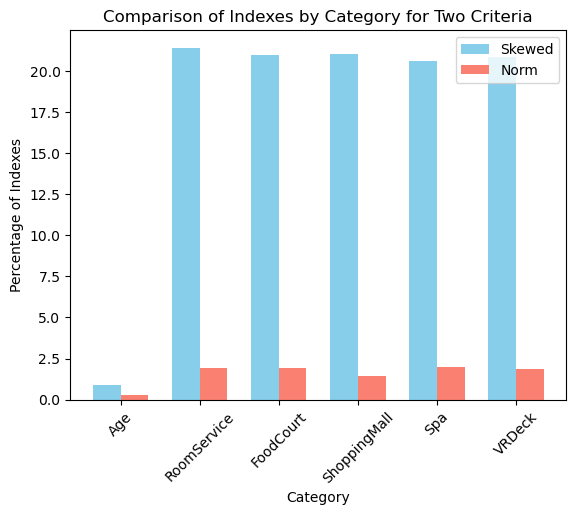

In [7]:
reload(tt)
total_length = train_data.shape[0]
idx_norm_outliers = tt.outliers_norm_distro(train_data, col_outliers)
idx_skewed_outliers = tt.outliers_skewed_distro(train_data, col_outliers)

#print(idx_skewed_outliers)
len_skewed = {ikey: len(ival) for ikey, ival in zip(idx_skewed_outliers.keys(), 
                                              idx_skewed_outliers.values())}
len_norm = {ikey: len(ival) for ikey, ival in zip(idx_norm_outliers.keys(), 
                                              idx_norm_outliers.values())}
# compare the two outliers algorithms
# Extract categories and their respective counts
categories = list(len_skewed.keys())
counts_skewed = list(len_skewed.values())
counts_norm = list(len_norm.values())

# Number of categories
num_categories = len(categories)
# Create an array for positioning the bars on the x-axis
indices = np.arange(num_categories)
# Width of each bar
bar_width = 0.35

# Plotting the grouped bar chart

plt.bar(indices, np.array(counts_skewed)/total_length*100, bar_width, label='Skewed', color='skyblue')
plt.bar(indices + bar_width, np.array(counts_norm)/total_length*100, bar_width, label='Norm', color='salmon')
# Adding labels, title, and legend
plt.xlabel('Category')
plt.ylabel('Percentage of Indexes')
plt.title('Comparison of Indexes by Category for Two Criteria')
plt.xticks(indices + bar_width / 2, categories, rotation=45)  # Position x-axis labels
plt.legend()

#wh_train_data = tt.replace_outlier_with_stats(train_data, col_outliers, method='mean')
train_data = tt.replace_outlier_with_stats(train_data, col_outliers, method=None)


In [8]:
display(train_data)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,False


# Split train-test

In [9]:
colnames = list(train_data.columns)
colnames_test = list(test_data.columns)
print(" Columns train", colnames)
print(" Columns test", colnames_test)
X_full = train_data[colnames[:-1]]
y_full = train_data[colnames[-1]]
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.30, random_state=42)

X_validation = test_data[colnames_test]

print(" Columns Xtr", list(X_train.columns))
print(" Columns Xte", list(X_validation.columns))

 Columns train ['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Name', 'Transported']
 Columns test ['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Name']
 Columns Xtr ['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Name']
 Columns Xte ['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Name']


In [10]:
X_train, y_train

(     PassengerId HomePlanet CryoSleep     Cabin    Destination   Age    VIP  \
 3032     3282_03     Europa     False   B/120/S    TRAPPIST-1e  43.0  False   
 7757     8276_02     Europa      True   C/273/P    TRAPPIST-1e  23.0  False   
 1795     1911_01      Earth     False   G/300/S    TRAPPIST-1e  46.0  False   
 1702     1808_01      Earth     False   F/346/S    TRAPPIST-1e  33.0  False   
 6634     6995_01      Earth     False  F/1334/S    55 Cancri e  24.0  False   
 ...          ...        ...       ...       ...            ...   ...    ...   
 5734     6076_01      Earth       NaN   G/988/S    TRAPPIST-1e  18.0  False   
 5191     5537_01       Mars     False  F/1063/S    TRAPPIST-1e  50.0    NaN   
 5390     5756_06      Earth     False  F/1194/P  PSO J318.5-22  22.0  False   
 860      0925_01       Mars     False   F/191/P    TRAPPIST-1e  34.0  False   
 7270     7775_01     Europa     False   C/253/P    55 Cancri e  28.0  False   
 
       RoomService  FoodCourt  Shoppin

# Nan's treatment

NaN values [  0 201 217 199 182 179 203 181 183 208 183 188 200   0]
NaN values PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64


Text(0.5, 1.0, 'NaN Values Count in Each Column')

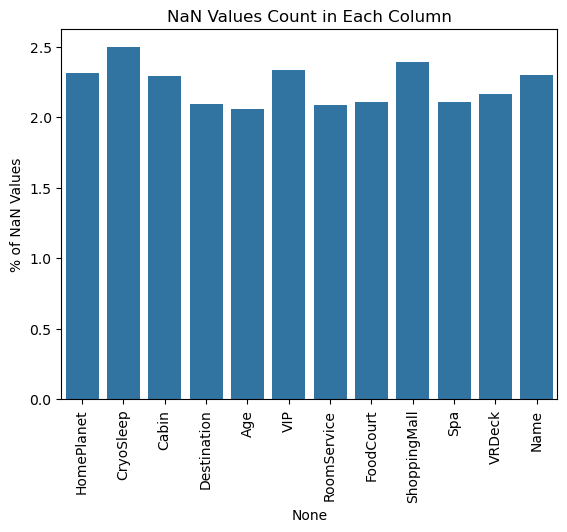

In [11]:
# Look at how many nan values we have in each category
# Approach 1
total_data = len(train_data) 
count_non_nans = np.array(train_data.count(axis=0) )
print("NaN values", total_data-count_non_nans)
# Approach 2
nan_counts = train_data[1:-1].isna().sum(axis=0)
print("NaN values", nan_counts)

sns.barplot(x=nan_counts[1:-1].index, y=nan_counts[1:-1].values/total_data*100)
plt.xticks(rotation=90) 
plt.ylabel('% of NaN Values')
plt.title('NaN Values Count in Each Column')

# Preprocessing Data
We will convert all data in numerical values to fed our NN. Since names are all differents, we deleted that column from our data in the first try 

__Preprocessing__ [TODO]
- Analyze correlations between features
- Implement PCA to reduce dimensionality

In [12]:
X_train.columns

Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name'],
      dtype='object')

In [13]:
def normalize_data(X, 
                   data_set='train',
                   deck_col_train=None,
                   side_col_train=None):
    
	## PassengerId: Convert PassengerId by family 
	rename_passId = lambda name: int(name.split("_")[0])
	X['PassengerId']= X['PassengerId'].apply(rename_passId)

	## HomePlanet (keeping NaN)
	# Generate multiple new features according the HomePlannet (OneHotEncoding)
	# ok print("HomePlanet", X['HomePlanet'].isna().sum())
	mask_nan = X['HomePlanet'].isna()
	X = pd.get_dummies(X, columns=['HomePlanet'], dtype=int)
	# Get all column names that start with 'HomePlanet_'
	homeplanet_columns = [col for col in X.columns if col.startswith('HomePlanet_')]
	X.loc[mask_nan, homeplanet_columns] = float('nan')
	# ok print("HomePlanet", X[homeplanet_columns].isna().sum())

	## Destination (keeping NaN)
	# Generate multiple new features according the Destination (OneHotEncoding)
	# ok print("Destination", X.Destination.isna().sum())
	mask_nan = X['Destination'].isna()
	X = pd.get_dummies(X, columns=['Destination'], dtype=int)
	# Get all column names that start with 'HomePlanet_'
	destination_columns = [col for col in X.columns if col.startswith('Destination_')]
	X.loc[mask_nan, destination_columns] = float('nan')
	# ok print("Destination", X[destination_columns].isna().sum())

	## CryoSleep & VIP
	#CryoSleep -> from bool to int
	label_mapping = {True: 1, False: 0}
	for ilabel in ['CryoSleep', 'VIP']:
		mask_nan = X[ilabel].isna()
		X[ilabel] = X[ilabel].map(label_mapping)
		X.loc[mask_nan, [ilabel]] = float('nan')

	## Cabin
	# Split the Cabin column into three different columns = deck/num/side to have better resolution
	#X.Cabin = X.Cabin.replace(to_replace = np.nan, value = 'nan/nan/nan')

	# Step 1: Split the Cabin column into Deck, Num, and Side
	X[['Deck', 'Num', 'Side']] = X['Cabin'].str.split('/', expand=True)

	# Step 2: Convert 'Num' to numeric (handling errors for NaN)
	X['Num'] = pd.to_numeric(X['Num'], errors='coerce')

	# Step 3: Handling NaN Values
	mask_nan = X['Cabin'].isna()
	X.loc[mask_nan, ['Deck', 'Num', 'Side']] = np.nan

	# Step 3: Handle missing values in 'Deck'
	# Create a boolean mask for rows where 'Deck' is NaN
	mask_nan_deck = X['Deck'].isna()
	mask_nan_deck = X['Side'].isna()

	# Step 4: One-hot encode 'Deck' and 'Side'
	X = pd.get_dummies(X, columns=['Deck'], drop_first=False)
	print("Side uniquevalues", X['Side'].unique())
	X = pd.get_dummies(X, columns=['Side'], drop_first=False)
	
	# Get all new columns starting with Deck_
	deck_columns = [col for col in X.columns if col.startswith('Deck_')]
	# Get all new columns starting with Side_
	side_columns = [col for col in X.columns if col.startswith('Side_')]
	# Check that columns from test dataset are present in the train dataset
	if data_set == 'test':
		missing_deck = set(deck_col_train) -set(deck_columns)
		missing_side = set(side_col_train) -set(side_columns)
		print("Missing Deck", missing_deck)
		print("Missing Side", missing_side)
		for col in missing_deck:
			X[col] = np.nan
			deck_columns.append(col)
		for col in missing_side:
			X[col] = np.nan
			side_columns.append(col)

	# Step 5: Drop the original Cabin column
	X.drop(columns=['Cabin'], inplace=True)

	# Step 6: Ensure NaN values are preserved
	X.loc[mask_nan, ['Num']] = np.nan
	X.loc[mask_nan, deck_columns] = np.nan
	X.loc[mask_nan, side_columns] = np.nan
	#for clabel in ['Deck', 'Side', 'Num']:
	#    X.loc[mask_nan, [clabel]] = float('nan')
	if data_set == 'train':
		return X, deck_columns, side_columns
	else:
		return X


# Remove Name from X_train and X_test
X_train_pp = X_train.copy()
X_test_pp = X_test.copy()
X_train_pp.drop(columns='Name', inplace=True)
X_test_pp.drop(columns='Name', inplace=True)
#X_train_svc = normalize_data(X_train_pp)
X_train_, deck_columns, side_columns = normalize_data(X_train_pp, 
                                                      data_set='train')
X_test_ = normalize_data(X_test_pp, 
                         data_set='test',
                         deck_col_train=deck_columns,
                         side_col_train=side_columns)
X_test_ = X_test_.reindex(columns=X_train_.columns)

print("Orig", train_data.isna().sum(axis=0).sum())
print("Prep", X_train_.isna().sum(axis=0).sum()+X_test_.isna().sum(axis=0).sum())
#print("Prep", X_test_.isna().sum(axis=0).sum())
print(201*2+199*2+182*2-200) #-200 because I deleted Name column for the analysis
print(2890-2324)
#

Side uniquevalues ['S' 'P' nan]
Side uniquevalues ['S' 'P' nan]
Missing Deck {'Deck_T'}
Missing Side set()
Orig 2324
Prep 7431
964
566


/tmp/ipykernel_7603/2873788804.py:84: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  X.loc[mask_nan, deck_columns] = np.nan
/tmp/ipykernel_7603/2873788804.py:85: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  X.loc[mask_nan, side_columns] = np.nan
/tmp/ipykernel_7603/2873788804.py:84: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  X.loc[mask_nan, deck_columns] = np.nan
/tmp/ipykernel_7603/2873788804.py:85: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future erro

In [14]:
display(len(X_train_.columns))
display(len(X_test_.columns))
display(X_train_.columns)

26

26

Index(['PassengerId', 'CryoSleep', 'Age', 'VIP', 'RoomService', 'FoodCourt',
       'ShoppingMall', 'Spa', 'VRDeck', 'HomePlanet_Earth',
       'HomePlanet_Europa', 'HomePlanet_Mars', 'Destination_55 Cancri e',
       'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'Num', 'Deck_A',
       'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T',
       'Side_P', 'Side_S'],
      dtype='object')

In [15]:
# Describe the DataFrame
print(X_train_.describe())

       PassengerId    CryoSleep          Age          VIP   RoomService  \
count  6085.000000  5931.000000  5956.000000  5932.000000   5971.000000   
mean   4641.224979     0.350700    28.853593     0.023432    228.270139   
std    2650.005024     0.477229    14.508935     0.151285    689.853570   
min       2.000000     0.000000     0.000000     0.000000      0.000000   
25%    2375.000000     0.000000    19.000000     0.000000      0.000000   
50%    4624.000000     0.000000    27.000000     0.000000      0.000000   
75%    6871.000000     1.000000    38.000000     0.000000     48.000000   
max    9280.000000     1.000000    79.000000     1.000000  14327.000000   

          FoodCourt  ShoppingMall           Spa        VRDeck  \
count   5963.000000   5939.000000   5963.000000   5956.000000   
mean     470.913969    172.940226    316.290626    309.114003   
std     1617.816200    623.964693   1129.433189   1184.515862   
min        0.000000      0.000000      0.000000      0.000000   

In [16]:
# Is it needed scale data?
print(X_train_.columns)
import plotly.express as px
def plot_scatter_matrices(X, y):
	fig1 = px.scatter_matrix(X, 
							dimensions=['CryoSleep', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'Spa'], 
							color=y,
							title="Selected Features: Age, VIP, RoomService, FoodCourt, CryoSleep")
	fig1.show()
	fig2 = px.scatter_matrix(X, 
							dimensions=['HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars'], 
							color=y,
							title="Selected Features: Home Planets")
	fig2.show()
	fig3 = px.scatter_matrix(X, 
							dimensions=['Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e'], 
							color=y, 
							title= "Selected Features: Destination")
	fig3.show()
	col_decks = [col for col in X.columns if col.startswith('Deck_')]
	fig4 = px.scatter_matrix(X, 
							dimensions=col_decks,#['Deck', 'Num', 'Side'], 
							color=y, 
							title= "Selected Features: Rooms -Deck")
	fig4.show()
    

plot_scatter_matrices(X_train_, y_train)

Index(['PassengerId', 'CryoSleep', 'Age', 'VIP', 'RoomService', 'FoodCourt',
       'ShoppingMall', 'Spa', 'VRDeck', 'HomePlanet_Earth',
       'HomePlanet_Europa', 'HomePlanet_Mars', 'Destination_55 Cancri e',
       'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'Num', 'Deck_A',
       'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T',
       'Side_P', 'Side_S'],
      dtype='object')


In [17]:
#X_train_, 
display(X_train_)
display(y_train)

,PassengerId,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,HomePlanet_Earth,...,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Side_P,Side_S
3032,3282,0.0,43.0,0.0,0.0,1440.0,0.0,85.0,150.0,0.0,...,False,True,False,False,False,False,False,False,False,True
7757,8276,1.0,23.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,True,False,False,False,False,False,True,False
1795,1911,0.0,46.0,0.0,8.0,652.0,0.0,5.0,90.0,1.0,...,False,False,False,False,False,False,True,False,False,True
1702,1808,0.0,33.0,0.0,0.0,763.0,8.0,2.0,30.0,1.0,...,False,False,False,False,False,True,False,False,False,True
6634,6995,0.0,24.0,0.0,0.0,58.0,618.0,0.0,41.0,1.0,...,False,False,False,False,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5734,6076,NaN,18.0,0.0,14.0,2.0,144.0,610.0,0.0,1.0,...,False,False,False,False,False,False,True,False,False,True
5191,5537,0.0,50.0,NaN,690.0,0.0,30.0,762.0,428.0,0.0,...,False,False,False,False,False,True,False,False,False,True
5390,5756,0.0,22.0,0.0,158.0,0.0,476.0,0.0,26.0,1.0,...,False,False,False,False,False,True,False,False,True,False
860,925,0.0,34.0,0.0,379.0,0.0,1626.0,0.0,0.0,0.0,...,False,False,False,False,False,True,False,False,True,False


3032     True
7757     True
1795    False
1702    False
6634    False
        ...  
5734     True
5191    False
5390    False
860     False
7270    False
Name: Transported, Length: 6085, dtype: bool

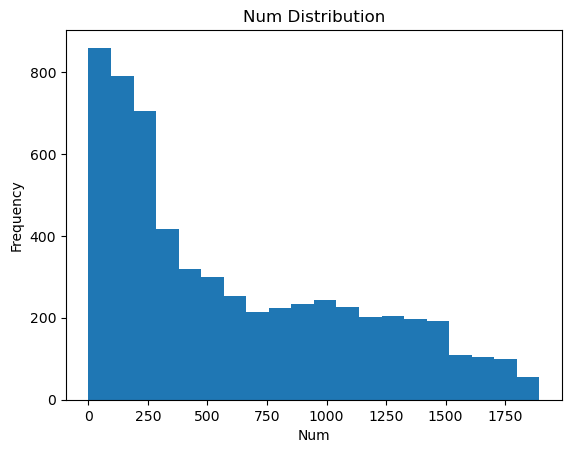

In [18]:
# Look at Num distribution
plt.hist(X_train_['Num'], bins=20)
plt.xlabel('Num')
plt.ylabel('Frequency')
plt.title('Num Distribution')
plt.show()


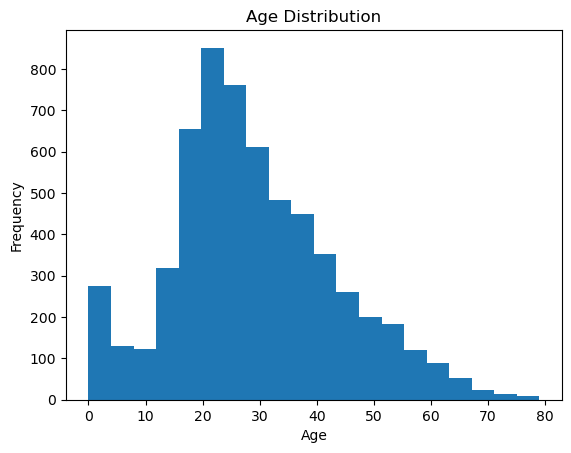

In [19]:
# Look at the Age distribution
plt.hist(X_train_['Age'], bins=20)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')
plt.show()

In [20]:
# Create two new features: TotalServices and GroupedAge
X_train_['TotalServices'] = X_train_[['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']].sum(axis=1)
X_test_['TotalServices'] = X_test_[['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']].sum(axis=1)

def grouped_age(X, 
                q=5, 
                data_set='train',
                groupedage_columns_train=None):

	# Group the 'Age' feature into bins maintaining the proportions of number of passengers in each bin
	# Each bin has to have the same number of passengers
	if data_set=='train':
		# Step 1: Use pd.qcut with retbins=True
		X['GroupedAge'], bins = pd.qcut(X['Age'], q=q, retbins=True)

		# Step 2: Generate dynamic labels based on bin edges
		labels = [f'{int(bins[i])}-{int(bins[i+1])}' for i in range(len(bins)-1)]

		# Step 3: Reassign the binned data with dynamic labels
		X['GroupedAge'] = pd.qcut(X['Age'], q=q, labels=labels)

		# Step 4: One-hot encode 'GroupedAge' and 'Side'
		X = pd.get_dummies(X, columns=['GroupedAge'], drop_first=False)
		print("GropuedAge uniquevalues", labels)
		return X, labels
	# Get all new columns starting with GroupedAge_
	groupedage_columns = [col for col in X.columns if col.startswith('GroupedAge_')]
	# Check that columns from test dataset are present in the train dataset
	if data_set == 'test':
		# Convert groupedage_columns_train into bins integers
		bins = [int(label.split('-')[0]) for label in groupedage_columns_train]
		bins.append(int(groupedage_columns_train[-1].split('-')[1]))
		X['GroupedAge'] = pd.cut(X['Age'], bins=bins, labels=groupedage_columns_train)
		
		X = pd.get_dummies(X, columns=['GroupedAge'], drop_first=False)

		return X

# # Group the 'Age' feature into bins maintaining the proportions of number of passengers in each bin
# # Each bin has to have the same number of passengers
# # Step 1: Use pd.qcut with retbins=True
# X_train_['GroupedAge'], bins = pd.qcut(X_train_['Age'], q=5, retbins=True)
# # Step 2: Generate dynamic labels based on bin edges
# labels = [f'{int(bins[i])}-{int(bins[i+1])}' for i in range(len(bins)-1)]
# # Step 3: Reassign the binned data with dynamic labels
# X_train_['GroupedAge'] = pd.qcut(X_train_['Age'], q=5, labels=labels)
X_train_, age_grouped_labels = grouped_age(X_train_, q=5, data_set='train')
X_test_ = grouped_age(X_test_, data_set='test', groupedage_columns_train=age_grouped_labels)

GropuedAge uniquevalues ['0-18', '18-24', '24-30', '30-41', '41-79']


In [21]:
X_train_.columns, X_test_.columns

(Index(['PassengerId', 'CryoSleep', 'Age', 'VIP', 'RoomService', 'FoodCourt',
        'ShoppingMall', 'Spa', 'VRDeck', 'HomePlanet_Earth',
        'HomePlanet_Europa', 'HomePlanet_Mars', 'Destination_55 Cancri e',
        'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'Num', 'Deck_A',
        'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T',
        'Side_P', 'Side_S', 'TotalServices', 'GroupedAge_0-18',
        'GroupedAge_18-24', 'GroupedAge_24-30', 'GroupedAge_30-41',
        'GroupedAge_41-79'],
       dtype='object'),
 Index(['PassengerId', 'CryoSleep', 'Age', 'VIP', 'RoomService', 'FoodCourt',
        'ShoppingMall', 'Spa', 'VRDeck', 'HomePlanet_Earth',
        'HomePlanet_Europa', 'HomePlanet_Mars', 'Destination_55 Cancri e',
        'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'Num', 'Deck_A',
        'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T',
        'Side_P', 'Side_S', 'TotalServices', 'GroupedAge_0-18',
     

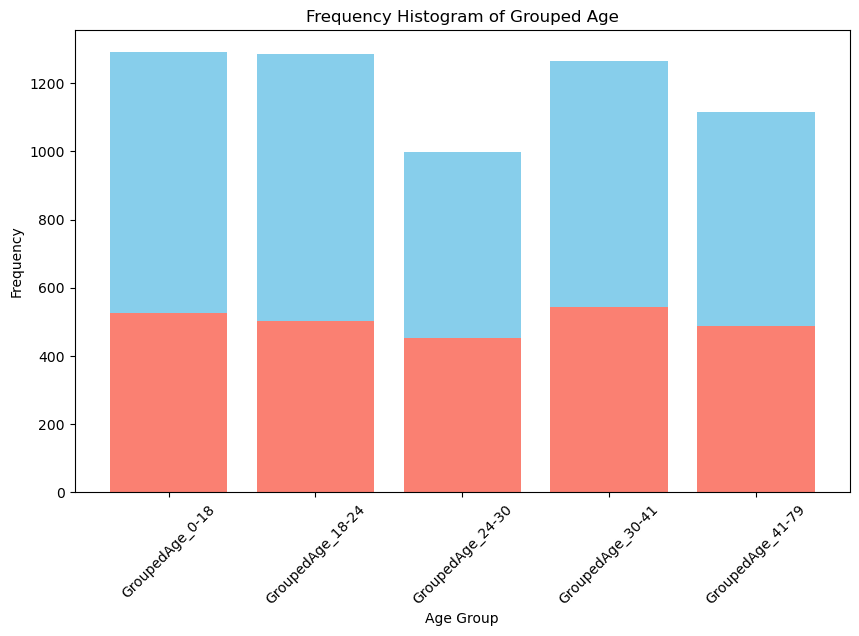

In [22]:
age_cols = [col for col in X_train_.columns if col.startswith('GroupedAge_')]
#px.histogram(X_train_, x=age_cols, barmode='group')
age_group_counts = X_train_[age_cols].sum()
age_group_counts_test = X_test_[age_cols].sum()
plt.figure(figsize=(10, 6))
plt.bar(age_group_counts.index, age_group_counts.values, color='skyblue')
plt.bar(age_group_counts_test.index, age_group_counts_test.values, color='salmon')
plt.title('Frequency Histogram of Grouped Age')
plt.xlabel('Age Group')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

In [23]:
columns_to_rescale = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Num']
columns_to_keep_unchanged = list(set(X_train_.columns) - set(columns_to_rescale))
# Step 1: Initialize the scaler
scaler = StandardScaler()

# Step 2: Fit the scaler on X_train
scaler.fit(X_train_[columns_to_rescale])

# Step 3: Transform X_train
subX_train_scaled = scaler.transform(X_train_[columns_to_rescale])

# Step 4: Transform X_test using the same scaler
subX_test_scaled = scaler.transform(X_test_[columns_to_rescale])

# Step 5: Create a copy of X_train_ and X_test_ to avoid modifying the original DataFrames
X_train_scaled = X_train_.copy()
X_test_scaled = X_test_.copy()

# Step 6: Replace the columns_to_rescale in the copied DataFrames with the scaled values
X_train_scaled[columns_to_rescale] = subX_train_scaled
X_test_scaled[columns_to_rescale] = subX_test_scaled

# (Optional) Convert back to DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_.columns, index=X_train_.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test_.columns, index=X_test_.index)

columns_to_keep_unchanged = list(set(X_train_.columns) - set(columns_to_rescale))
# Convert to numeric all the columns
X_train_scaled[columns_to_keep_unchanged] = X_train_scaled[columns_to_keep_unchanged].apply(pd.to_numeric)

In [24]:
X_train_scaled.iloc[0:5, :]

,PassengerId,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,HomePlanet_Earth,...,Deck_G,Deck_T,Side_P,Side_S,TotalServices,GroupedAge_0-18,GroupedAge_18-24,GroupedAge_24-30,GroupedAge_30-41,GroupedAge_41-79
3032,3282,0.0,0.975095,0.0,-0.330924,0.599059,-0.277187,-0.204802,-0.134340,0.0,...,0.0,0.0,0.0,1.0,1675.0,False,False,False,False,True
7757,8276,1.0,-0.403481,0.0,-0.330924,-0.291104,-0.277187,-0.280067,-0.260984,0.0,...,0.0,0.0,1.0,0.0,0.0,False,True,False,False,False
1795,1911,0.0,1.181882,0.0,-0.319327,0.111942,-0.277187,-0.275640,-0.184997,1.0,...,1.0,0.0,0.0,1.0,755.0,False,False,False,False,True
1702,1808,0.0,0.285807,0.0,-0.330924,0.180559,-0.264364,-0.278296,-0.235655,1.0,...,0.0,0.0,0.0,1.0,803.0,False,False,False,True,False
6634,6995,0.0,-0.334552,0.0,-0.330924,-0.255251,0.713337,-0.280067,-0.226368,1.0,...,0.0,0.0,0.0,1.0,717.0,False,True,False,False,False


In [25]:
plot_scatter_matrices(X_train_scaled, y_train)

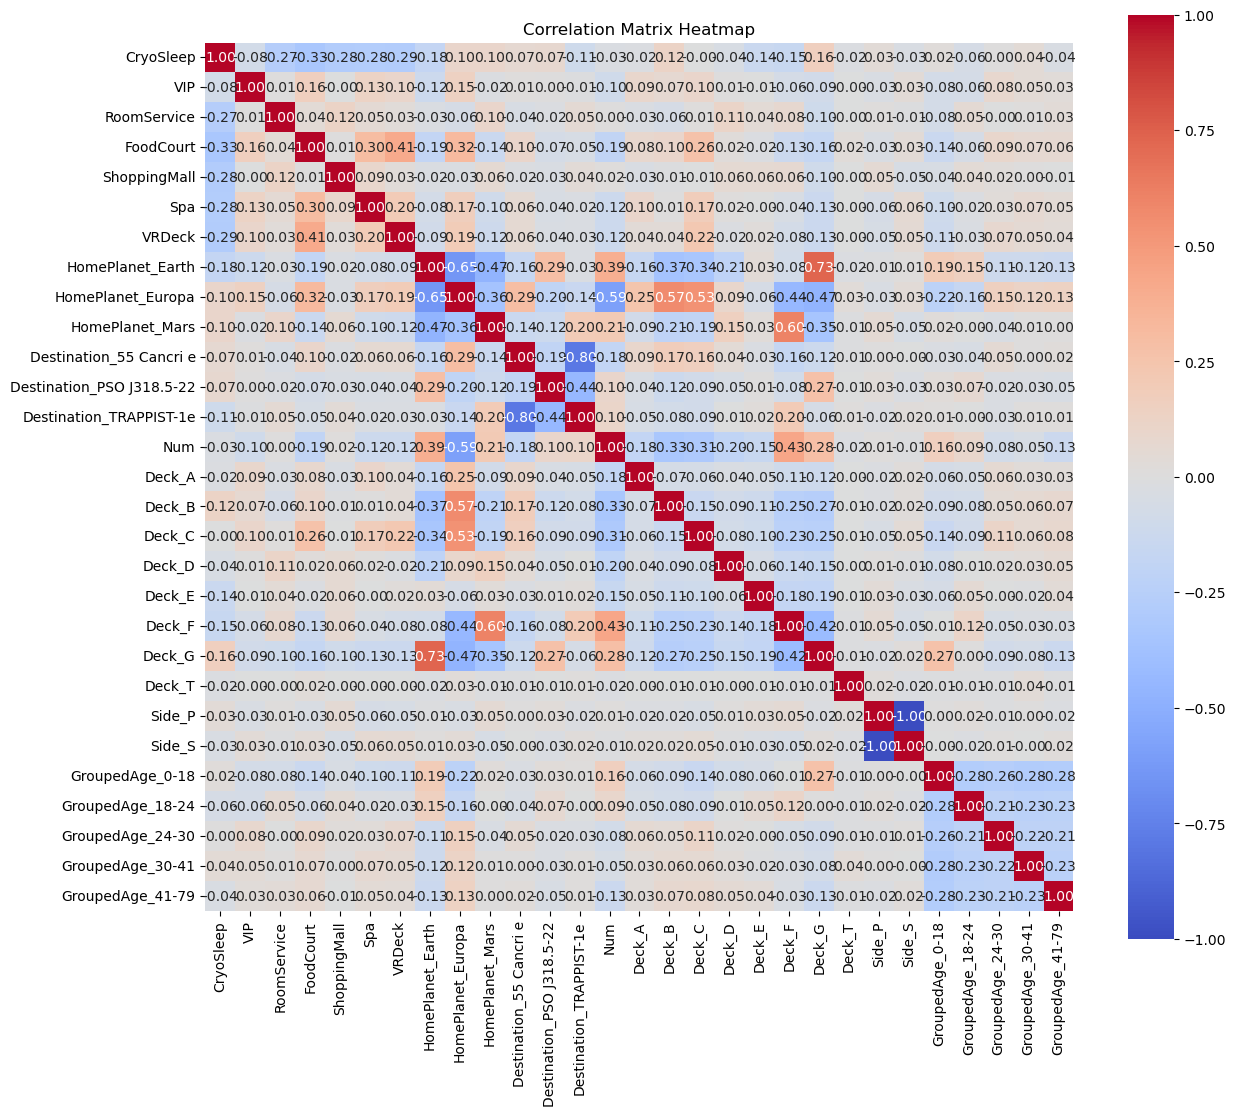

Highly correlated feature pairs (above the threshold):
('Side_P', 'Side_S')
Explained variance [2.37419169e-01 2.06220483e-01 1.31719085e-01 6.49385829e-02
 6.25364023e-02 4.78398513e-02 3.42202017e-02 2.86865451e-02
 2.41970667e-02 2.33562606e-02 2.23004477e-02 2.07869055e-02
 1.92763443e-02 1.59316128e-02 1.37302699e-02 1.10628301e-02
 8.80285294e-03 6.77661333e-03 5.89747752e-03 5.65277502e-03
 4.77103867e-03 2.01084857e-03 1.29074456e-03 5.16437127e-04
 5.91541269e-05 9.51886569e-18 0.00000000e+00 0.00000000e+00
 0.00000000e+00]


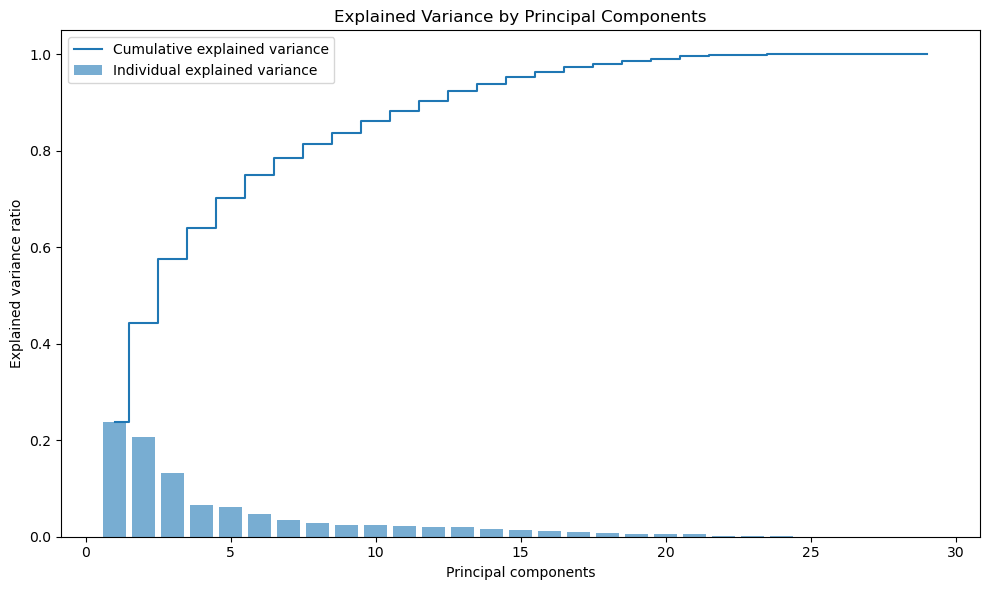

Number of components to retain 97.0% variance: 17 out of 29


In [26]:
preproc = True
if preproc:
    # Define inner database
    data_to_inspect=X_train_scaled.loc[y_train[y_train==True].index]
    
    # Drop passangerId
    data_to_inspect.drop(columns='PassengerId', inplace=True)
    data_to_inspect.drop(columns='TotalServices', inplace=True)
    data_to_inspect.drop(columns='Age', inplace=True)
    
    # Compute the correlation matrix with the transported passengers
    corr_matrix = data_to_inspect.corr()

    # Plotting the correlation matrix as a heatmap
    plt.figure(figsize=(14, 12))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', 
                cmap='coolwarm', cbar=True, square=True)
    plt.title('Correlation Matrix Heatmap')
    plt.show()

    # Set a correlation threshold (e.g., 0.85)
    threshold = 0.85

    # Find pairs of features that are highly correlated
    high_corr_pairs = np.where(np.abs(corr_matrix) > threshold)
    high_corr_pairs = [(corr_matrix.index[x], corr_matrix.columns[y]) for x, y in zip(*high_corr_pairs) if x != y and x < y]

    print("Highly correlated feature pairs (above the threshold):")
    for pair in high_corr_pairs:
        print(pair)

    ##########################
    ##########
    ########## Applying Preprocessing to the data.
    ##########
    ###########################
    # Step 2: Apply PCA
    pca = PCA()  # You can also specify the number of components like PCA(n_components=5)
    X_pca = pca.fit_transform(data_to_inspect.dropna())

    # Step 3: Analyze the explained variance
    explained_variance = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance)
    print("Explained variance", explained_variance)
    # Step 4: Plot the explained variance and cumulative variance
    plt.figure(figsize=(10, 6))
    plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.6, label='Individual explained variance')
    plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid', label='Cumulative explained variance')
    plt.xlabel('Principal components')
    plt.ylabel('Explained variance ratio')
    plt.title('Explained Variance by Principal Components')
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

    # Step 5: Select the number of components (e.g., for pctg% variance)
    pctg=0.97
    n_components = np.argmax(cumulative_variance >= pctg) + 1
    print(f'Number of components to retain {pctg*100}% variance: {n_components} out of {len(data_to_inspect.columns)}')

    ## Step 6: Transform the dataset with the selected number of components
    #pca_final = PCA(n_components=n_components)
    #X_reduced = pca_final.fit_transform(data_to_inspect)
    #print(f"Original shape: {X_train_.shape}")
    #print(f"Reduced shape after PCA: {X_reduced.shape}")

# ML algorithm

In [27]:
def apply_imputation(X, strategy='mean'):
    """It applies imputation to handle NaN in SVC models.
    
    It returns 'imp' object to transform data like: imp.transform(X)"""
    
    imp = SimpleImputer(missing_values=np.nan, strategy=strategy)
    imp = imp.fit(X)
    x_imp = imp.transform(X)
    return x_imp
def compute_metrics(y_true, y_pred, mode='binary', y_prob=None):
    precision = precision_score(y_true, y_pred, average=mode)
    recall = recall_score(y_true, y_pred, average=mode)
    f1 = f1_score(y_true, y_pred, average=mode)
    accuracy = accuracy_score(y_true, y_pred)
    if y_prob is None:
        roc_auc = roc_auc_score(y_true, y_pred)
    else: 
        roc_auc = roc_auc_score(y_true, y_prob)
    
    return [precision, recall, f1, accuracy, roc_auc]


In [28]:
mask_plus_three_nan = X_train_scaled.isna().sum(axis=1)<=3
# Remove rows where there are more than 3 NaN values
X_to_train = X_train_scaled.loc[mask_plus_three_nan]
y_to_train = y_train.loc[mask_plus_three_nan]

In [205]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)
print("Before", X_to_train.isna().sum().sum())
#X = pd.DataFrame(imputer.fit_transform(X_to_train), columns=X_to_train.columns)
X = pd.DataFrame(imputer.fit_transform(X_train_scaled), columns=X_train_scaled.columns)
x_test = pd.DataFrame(imputer.transform(X_test_scaled), columns=X_test_scaled.columns)
print("After", pd.DataFrame(X).isna().sum().sum())
display(X)

Before 1667
After 0


,PassengerId,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,HomePlanet_Earth,...,Deck_G,Deck_T,Side_P,Side_S,TotalServices,GroupedAge_0-18,GroupedAge_18-24,GroupedAge_24-30,GroupedAge_30-41,GroupedAge_41-79
0,3282.0,0.0,0.975095,0.0,-0.330924,0.599059,-0.277187,-0.204802,-0.134340,0.0,...,0.0,0.0,0.0,1.0,1675.0,0.0,0.0,0.0,0.0,1.0
1,8276.0,1.0,-0.403481,0.0,-0.330924,-0.291104,-0.277187,-0.280067,-0.260984,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1911.0,0.0,1.181882,0.0,-0.319327,0.111942,-0.277187,-0.275640,-0.184997,1.0,...,1.0,0.0,0.0,1.0,755.0,0.0,0.0,0.0,0.0,1.0
3,1808.0,0.0,0.285807,0.0,-0.330924,0.180559,-0.264364,-0.278296,-0.235655,1.0,...,0.0,0.0,0.0,1.0,803.0,0.0,0.0,0.0,1.0,0.0
4,6995.0,0.0,-0.334552,0.0,-0.330924,-0.255251,0.713337,-0.280067,-0.226368,1.0,...,0.0,0.0,0.0,1.0,717.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6080,6076.0,0.0,-0.748125,0.0,-0.310628,-0.289868,-0.046385,0.260072,-0.260984,1.0,...,1.0,0.0,0.0,1.0,770.0,1.0,0.0,0.0,0.0,0.0
6081,5537.0,0.0,1.457597,0.0,0.669372,-0.291104,-0.229103,0.394664,0.100375,0.0,...,0.0,0.0,0.0,1.0,1910.0,0.0,0.0,0.0,0.0,1.0
6082,5756.0,0.0,-0.472410,0.0,-0.101871,-0.291104,0.485741,-0.280067,-0.239032,1.0,...,0.0,0.0,1.0,0.0,660.0,0.0,1.0,0.0,0.0,0.0
6083,925.0,0.0,0.354736,0.0,0.218514,-0.291104,2.328949,-0.280067,-0.260984,0.0,...,0.0,0.0,1.0,0.0,2005.0,0.0,0.0,0.0,1.0,0.0


In [193]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

imputer = IterativeImputer()
X = pd.DataFrame(imputer.fit_transform(X_train_scaled), columns=X_train_scaled.columns)
x_test = pd.DataFrame(imputer.transform(X_test_scaled), columns=X_test_scaled.columns)
display(X)

,PassengerId,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,HomePlanet_Earth,...,Deck_G,Deck_T,Side_P,Side_S,TotalServices,GroupedAge_0-18,GroupedAge_18-24,GroupedAge_24-30,GroupedAge_30-41,GroupedAge_41-79
0,3282.0,0.000000,0.975095,0.000000,-0.330924,0.599059,-0.277187,-0.204802,-0.134340,0.0,...,0.0,0.0,0.0,1.0,1675.0,0.0,0.0,0.0,0.0,1.0
1,8276.0,1.000000,-0.403481,0.000000,-0.330924,-0.291104,-0.277187,-0.280067,-0.260984,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1911.0,0.000000,1.181882,0.000000,-0.319327,0.111942,-0.277187,-0.275640,-0.184997,1.0,...,1.0,0.0,0.0,1.0,755.0,0.0,0.0,0.0,0.0,1.0
3,1808.0,0.000000,0.285807,0.000000,-0.330924,0.180559,-0.264364,-0.278296,-0.235655,1.0,...,0.0,0.0,0.0,1.0,803.0,0.0,0.0,0.0,1.0,0.0
4,6995.0,0.000000,-0.334552,0.000000,-0.330924,-0.255251,0.713337,-0.280067,-0.226368,1.0,...,0.0,0.0,0.0,1.0,717.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6080,6076.0,0.504075,-0.748125,0.000000,-0.310628,-0.289868,-0.046385,0.260072,-0.260984,1.0,...,1.0,0.0,0.0,1.0,770.0,1.0,0.0,0.0,0.0,0.0
6081,5537.0,0.000000,1.457597,0.048129,0.669372,-0.291104,-0.229103,0.394664,0.100375,0.0,...,0.0,0.0,0.0,1.0,1910.0,0.0,0.0,0.0,0.0,1.0
6082,5756.0,0.000000,-0.472410,0.000000,-0.101871,-0.291104,0.485741,-0.280067,-0.239032,1.0,...,0.0,0.0,1.0,0.0,660.0,0.0,1.0,0.0,0.0,0.0
6083,925.0,0.000000,0.354736,0.000000,0.218514,-0.291104,2.328949,-0.280067,-0.260984,0.0,...,0.0,0.0,1.0,0.0,2005.0,0.0,0.0,0.0,1.0,0.0


In [206]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(random_state=0,
                         C=1,
                         max_iter=10000).fit(X.drop(columns='PassengerId') , y_train)

clf.score(x_test.drop(columns='PassengerId'), y_test)

0.781058282208589

In [207]:
# Apply XGBooster
#Creating an XGBoost classifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report

model = xgb.XGBClassifier()

#Training the model on the training data
model.fit(X.drop(columns='PassengerId'), y_train)

#Making predictions on the test set
predictions = model.predict(x_test.drop(columns='PassengerId'))

#Calculating accuracy
accuracy = accuracy_score(y_test, predictions)

In [208]:
print("Accuracy:", accuracy)
print("\nClassification Report:")

print(classification_report(y_test, predictions))

Accuracy: 0.8006134969325154

Classification Report:
              precision    recall  f1-score   support

       False       0.80      0.80      0.80      1289
        True       0.80      0.80      0.80      1319

    accuracy                           0.80      2608
   macro avg       0.80      0.80      0.80      2608
weighted avg       0.80      0.80      0.80      2608

